In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [ ]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPUs: {gpus}")
    print("GPU is available. Using GPU.")
else:
    print("No GPU found. Using CPU.")


Found 1 GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available. Using GPU.


### Vision Transformer (ViT) Model Setup and Training

Now, let's set up and train a basic Vision Transformer (ViT) model. We'll start by defining the model parameters and preparing the dataset.

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pathlib
import os # Added import os

# Define model parameters
IMG_SIZE = 224  # Image size
PATCH_SIZE = 16  # Size of the patches to be extracted from the input images
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 32  # Dimension for patch embeddings (Reduced from 64)
TRANSFORMER_LAYERS = 4 # Number of transformer blocks (Reduced from 8)
NUM_HEADS = 4  # Number of attention heads
TRANSFORMER_UNITS = [ # Size of the transformer layers
    PROJECTION_DIM * 2,
    PROJECTION_DIM,
]
MLP_HEAD_UNITS = [1024, 512]  # Reduced MLP head units
NUM_CLASSES = 2  # Cat and Dog
BATCH_SIZE = 32

# Load the dataset using the path from the previous cell
# Assuming the dataset structure is 'path/training_set/cat/', 'path/training_set/dog/', 'path/test_set/cat/', 'path/test_set/dog/'
data_dir = pathlib.Path(path)

# --- Proposed fix for nested directory structure ---
print(f"Contents of downloaded path ({data_dir}): {os.listdir(data_dir)}")

# Check if the dataset is nested within another folder (common for Kaggle datasets)
# Example: /kaggle/input/cat-and-dog/cat-and-dog/
if (data_dir / 'cat-and-dog').is_dir():
    data_dir = data_dir / 'cat-and-dog'
    print(f"Adjusted data_dir to: {data_dir} (found nested 'cat-and-dog' directory)")

# Further adjust for another common nesting pattern: training_set/training_set
if (data_dir / 'training_set' / 'training_set').is_dir():
    train_dir = data_dir / 'training_set' / 'training_set'
    val_dir = data_dir / 'test_set' / 'test_set'
    print(f"Adjusted train_dir to: {train_dir} and val_dir to: {val_dir} (found nested 'training_set/training_set' and 'test_set/test_set')")
else:
    train_dir = data_dir / 'training_set'
    val_dir = data_dir / 'test_set'

# --- End of proposed fix ---

try:
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_SIZE, IMG_SIZE),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        val_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_SIZE, IMG_SIZE),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=False # No need to shuffle validation data
    )
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure the dataset structure under '{data_dir}' has 'training_set' and 'test_set' subdirectories, each containing 'cat' and 'dog' folders with images, possibly nested.")
    # Create dummy data for demonstration if actual data loading fails
    print("Creating dummy data for demonstration purposes.")
    train_ds = tf.data.Dataset.from_tensor_slices((tf.random.uniform(shape=(100, IMG_SIZE, IMG_SIZE, 3)), tf.random.uniform(shape=(100,), minval=0, maxval=2, dtype=tf.int32)))
    train_ds = train_ds.batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((tf.random.uniform(shape=(20, IMG_SIZE, IMG_SIZE, 3)), tf.random.uniform(shape=(20,), minval=0, maxval=2, dtype=tf.int32)))
    val_ds = val_ds.batch(BATCH_SIZE)


# Data augmentation and normalization
data_augmentation = keras.Sequential(
    [
        layers.Rescaling(1.0 / 255),
        layers.Normalization(),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)

# Adapt the Normalization layer to the training data
# Create a small dataset for adaptation
adaptation_ds = train_ds.map(lambda x, y: x).take(1)
for x in adaptation_ds:
    data_augmentation.layers[1].adapt(x)

# Apply augmentation to the training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=tf.data.AUTOTUNE)

# Prefetching for performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Number of patches: {NUM_PATCHES}")
print(f"Projection Dimension: {PROJECTION_DIM}")
print(f"Number of Transformer Layers: {TRANSFORMER_LAYERS}")

Contents of downloaded path (/kaggle/input/cat-and-dog): ['test_set', 'training_set']
Adjusted train_dir to: /kaggle/input/cat-and-dog/training_set/training_set and val_dir to: /kaggle/input/cat-and-dog/test_set/test_set (found nested 'training_set/training_set' and 'test_set/test_set')
Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.
Image size: 224x224
Patch size: 16x16
Number of patches: 196
Projection Dimension: 32
Number of Transformer Layers: 4


#### ViT Model Components

Here, we define the custom layers required for the Vision Transformer: `Patches` to extract image patches, `PatchEncoder` to embed these patches, and `TransformerBlock` for the self-attention mechanism.

In [ ]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation="gelu"),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None): # Added training=None
        attn_output = self.att(inputs, inputs, training=training) # Pass training to attention
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


#### Build and Compile the ViT Model

We now assemble the layers to create the full Vision Transformer model and then compile it for training.

In [ ]:
def create_vit_classifier():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Create patches
    patches = Patches(PATCH_SIZE)(inputs)
    # Encode patches
    encoded_patches = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)

    # Create multiple transformer blocks
    for _ in range(TRANSFORMER_LAYERS):
        encoded_patches = TransformerBlock(
            PROJECTION_DIM, NUM_HEADS, TRANSFORMER_UNITS[0]
        )(encoded_patches)

    # Create a [CLS] token like output by taking the mean of all patches.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)

    # Add MLP head.
    for dim in MLP_HEAD_UNITS:
        representation = layers.Dense(dim, activation="gelu")(representation)
        representation = layers.Dropout(0.5)(representation)
    logits = layers.Dense(NUM_CLASSES, activation='softmax')(representation)

    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

# Build the model
vit_model = create_vit_classifier()

# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
vit_model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)

print("ViT model created and compiled.")
vit_model.summary()


ViT model created and compiled.


Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_44 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patches_6 (Patches)             │ (None, None, 768)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_encoder_6 (PatchEncoder)  │ (None, 196, 32)        │        30,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_34            │ (None, 196, 32)        │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_35            │ (None, 196, 32)        │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_36            │ (None, 196, 32)        │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_37            │ (None, 196, 32)        │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_80          │ (None, 196, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_124 (Dropout)           │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 1024)           │     6,423,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_125 (Dropout)           │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_126 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,064,802 (26.95 MB)

 Trainable params: 7,064,802 (26.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Re-run model definition and compilation as TransformerBlock was updated
def create_vit_classifier():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Create patches
    patches = Patches(PATCH_SIZE)(inputs)
    # Encode patches
    encoded_patches = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)

    # Create multiple transformer blocks
    for _ in range(TRANSFORMER_LAYERS):
        encoded_patches = TransformerBlock(
            PROJECTION_DIM, NUM_HEADS, TRANSFORMER_UNITS[0]
        )(encoded_patches)

    # Create a [CLS] token like output by taking the mean of all patches.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)

    # Add MLP head.
    for dim in MLP_HEAD_UNITS:
        representation = layers.Dense(dim, activation="gelu")(representation)
        representation = layers.Dropout(0.5)(representation)
    logits = layers.Dense(NUM_CLASSES, activation='softmax')(representation)

    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

# Build the model
vit_model = create_vit_classifier()

# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=5e-5) # Adjusted learning rate
vit_model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)

print("ViT model created and compiled with updated TransformerBlock and hyperparameters.")
vit_model.summary()

ViT model created and compiled with updated TransformerBlock and hyperparameters.


Model: "functional_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_49 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patches_7 (Patches)             │ (None, None, 768)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_encoder_7 (PatchEncoder)  │ (None, 196, 32)        │        30,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_38            │ (None, 196, 32)        │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_39            │ (None, 196, 32)        │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_40            │ (None, 196, 32)        │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_41            │ (None, 196, 32)        │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_89          │ (None, 196, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_139 (Dropout)           │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 1024)           │     6,423,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_140 (Dropout)           │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_141 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,064,802 (26.95 MB)

 Trainable params: 7,064,802 (26.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Re-run training with corrected data loading
epochs = 20  # You can adjust the number of epochs

# Add callbacks for early stopping and model checkpointing
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("Starting model training with adjusted hyperparameters...")
history = vit_model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping]
)
print("Model training finished.")

Starting model training with adjusted hyperparameters...
Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 493ms/step - accuracy: 0.5001 - loss: 1.0661 - top-5-accuracy: 1.0000 - val_accuracy: 0.5002 - val_loss: 0.6971 - val_top-5-accuracy: 1.0000
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 110s 424ms/step - accuracy: 0.5016 - loss: 0.8249 - top-5-accuracy: 1.0000 - val_accuracy: 0.4998 - val_loss: 0.6933 - val_top-5-accuracy: 1.0000
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 107s 426ms/step - accuracy: 0.4969 - loss: 0.7668 - top-5-accuracy: 1.0000 - val_accuracy: 0.5002 - val_loss: 0.6942 - val_top-5-accuracy: 1.0000
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 127s 506ms/step - accuracy: 0.4979 - loss: 0.7299 - top-5-accuracy: 1.0000 - val_accuracy: 0.4998 - val_loss: 0.6942 - val_top-5-accuracy: 1.0000
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 107s 425ms/step - accuracy: 0.5031 - loss: 0.7129 - top-5-accuracy: 1.0000 - val_accuracy: 0.4998 - val_loss: 0.6932 - val_top-5-accuracy: 1.0000
Epoch 6/20
25

### Training Results Summary

Let's evaluate the trained model and print a summary of its performance on the validation set.

In [ ]:
# Re-evaluate the model after training
loss, accuracy, top_5_accuracy = vit_model.evaluate(val_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Top-5 Accuracy: {top_5_accuracy:.4f}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 340ms/step - accuracy: 0.5002 - loss: 0.6931 - top-5-accuracy: 1.0000
Test Loss: 0.6931
Test Accuracy: 0.5002
Test Top-5 Accuracy: 1.0000


### Training History Visualization

Finally, let's visualize the training and validation accuracy and loss over epochs to understand the model's learning progress.

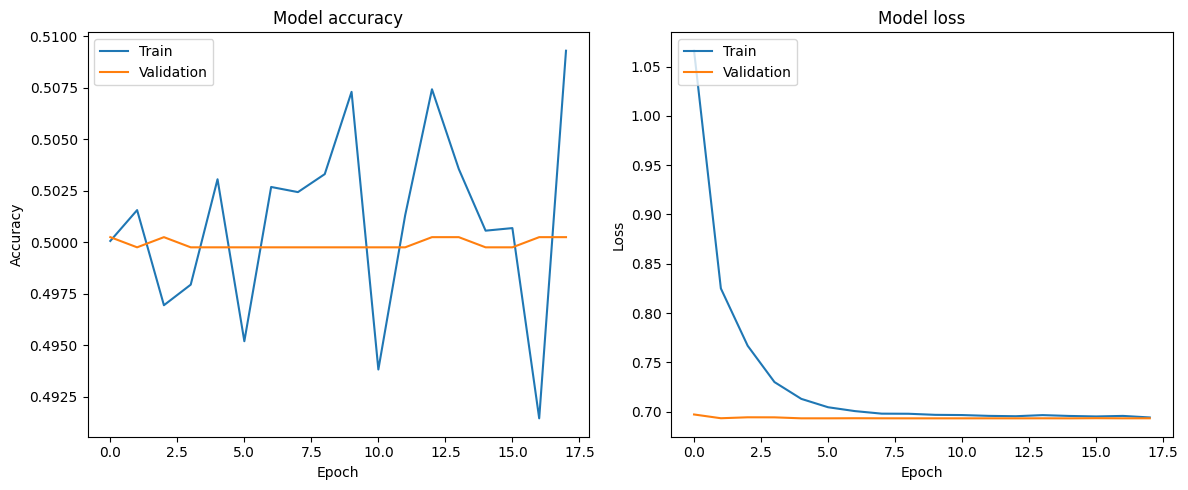

In [ ]:
# Re-plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

#### Train the ViT Model

Now we will train the Vision Transformer model using the prepared dataset.

In [ ]:
# Re-run training with corrected data loading
epochs = 20  # You can adjust the number of epochs

# Add callbacks for early stopping and model checkpointing
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("Starting model training with corrected dataset...")
history = vit_model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping]
)
print("Model training finished.")

Starting model training with corrected dataset...
Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 107s 424ms/step - accuracy: 0.4937 - loss: 0.6968 - top-5-accuracy: 1.0000 - val_accuracy: 0.4998 - val_loss: 0.6932 - val_top-5-accuracy: 1.0000
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 105s 418ms/step - accuracy: 0.5079 - loss: 0.6973 - top-5-accuracy: 1.0000 - val_accuracy: 0.4998 - val_loss: 0.6938 - val_top-5-accuracy: 1.0000
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 106s 421ms/step - accuracy: 0.5057 - loss: 0.6948 - top-5-accuracy: 1.0000 - val_accuracy: 0.5002 - val_loss: 0.6932 - val_top-5-accuracy: 1.0000
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 105s 417ms/step - accuracy: 0.4909 - loss: 0.6972 - top-5-accuracy: 1.0000 - val_accuracy: 0.5002 - val_loss: 0.6932 - val_top-5-accuracy: 1.0000
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 127s 504ms/step - accuracy: 0.5018 - loss: 0.6976 - top-5-accuracy: 1.0000 - val_accuracy: 0.5002 - val_loss: 0.6932 - val_top-5-accuracy: 1.0000
Epoch 6/20
251/251 ━

In [ ]:
# Re-evaluate the model after training
loss, accuracy, top_5_accuracy = vit_model.evaluate(val_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Top-5 Accuracy: {top_5_accuracy:.4f}")

In [ ]:
# Re-plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()